# Setup data

In [1]:
import torch
from scipy.special import softmax

def load_params(model_path, weights_only=False):
    # 1) Load parameters
    model_data = torch.load(model_path, map_location=torch.device('cpu'), weights_only=weights_only)
    theta = model_data['theta']          # shape: (n_people, k)
    d = model_data['d']                  # shape: (n_items,  k)
    p = model_data['phi']

    print("--- Initial Loaded Data ---")
    print(f"Original theta shape: {theta.shape}")
    print(f"Original 'd' matrix shape: {d.shape}\n")

    d_numpy = d.detach().cpu().numpy()
    theta_numpy = theta.detach().cpu().numpy()
    p_numpy = p.detach().cpu().numpy()
    w_numpy = softmax(p_numpy, axis=1)
    return d_numpy, theta_numpy, p_numpy, w_numpy

In [2]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.append('..')
import style
# Concatenate math and gsm outputs for theta, a, b

d, theta, p, w = load_params('../result/lada-fitting-joint/lada_joint_k2_legalbench.pt', weights_only=False)

resmat = pd.read_pickle('../data-reeval-multi/resmat.pkl')

conv = ['legalbench']
conv_mask = resmat.loc[:, resmat.columns.get_level_values("scenario").isin(conv)]

conv_questions = conv_mask.columns.get_level_values('input.text').tolist()

answers_path = Path('../data-processing/legalbench/legalbench_result.pkl')
if not answers_path.exists():
    raise FileNotFoundError(f'Expected answer key at {answers_path} was not found. Run the assembly script first.')
answer_df = pd.read_pickle(answers_path)
answer_frame = answer_df.loc['answer'].rename('answer').reset_index()
type_frame = answer_df.loc['type'].rename('type').reset_index()
answer_frame['scenario'] = answer_frame['scenario'].astype(str).str.lower()
type_frame['scenario'] = type_frame['scenario'].astype(str).str.lower()
merged_answers = answer_frame.merge(
    type_frame[['scenario', 'input.text', 'type']],
    on=['scenario', 'input.text'],
    how='left'
 )
answer_map = merged_answers[merged_answers['scenario'] == 'legalbench'].set_index('input.text')[['answer', 'type']]
answers_aligned = answer_map.reindex(conv_questions)
if answers_aligned['answer'].isna().any() or answers_aligned['type'].isna().any():
    missing_answers = answers_aligned[answers_aligned['answer'].isna()].index.tolist()
    missing_types = answers_aligned[answers_aligned['type'].isna()].index.tolist()
    raise ValueError(
        'Missing answers or types for prompts. '
        f'Missing answers: {missing_answers[:5]} | Missing types: {missing_types[:5]}'
    )

theta_df = pd.DataFrame(theta, columns=[f'Factor_{i+1}' for i in range(theta.shape[1])], index=resmat.index)
w_df = pd.DataFrame(w, columns=[f'Factor_{i+1}' for i in range(w.shape[1])])
w_df['question'] = conv_questions
w_df['answer'] = answers_aligned['answer'].values
w_df['type'] = answers_aligned['type'].values

models_answered = conv_mask.dropna(how='all').index.tolist()
accuracy = (conv_mask.sum(axis=1) / conv_mask.notnull().sum(axis=1)).loc[models_answered]
theta_irt = pd.read_csv('../result/irt-fitting/calibration_result_theta_legalbench.csv')
theta_df = theta_df.loc[models_answered]
theta_df['accuracy'] = accuracy
theta_df['irt'] = theta_irt.values

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 2])
Original 'd' matrix shape: torch.Size([1997])



In [3]:
import os

os.makedirs('../output/lada', exist_ok=True)

export_cols = ['Factor_1', 'Factor_2', 'question', 'answer', 'type']
available_cols = [col for col in export_cols if col in w_df.columns]
w_export = w_df[available_cols]
w_export.to_csv(f'../output/lada/legalbench_lada_2k.csv', index=False)
w_export.sort_values(by=['Factor_1'], ascending=False).to_csv(f'../output/lada/legalbench_lada_2k_f1_desc.csv', index=False)
w_export.sort_values(by=['Factor_2'], ascending=False).to_csv(f'../output/lada/legalbench_lada_2k_f2_desc.csv', index=False)

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_30251/3364916728.py:119: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


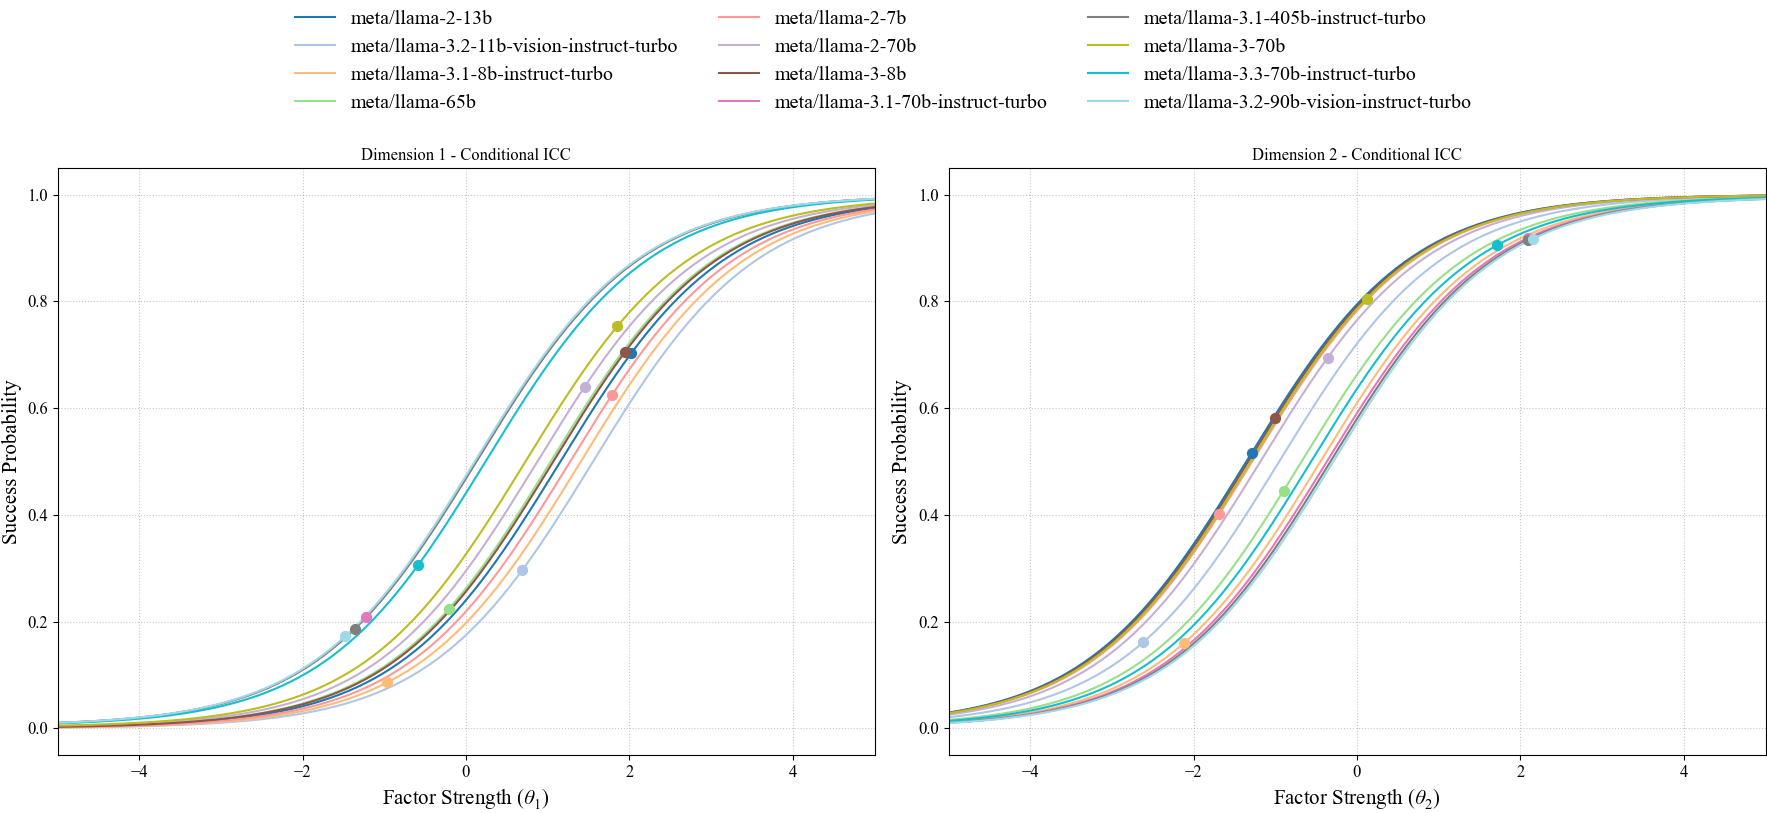

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
from calculate_p_lada import lada_probability

def plot_conditional_iccs_for_models_lada(theta_df, w_df, d_array, labels_to_plot):
    """
    Plots Conditional Item Characteristic Curves for a list of models using LADA parameters.
    Each model gets its own shifted curve based on a model-specific representative item.
    
    Key insight: We create a composite "representative item" for each model by:
    1. Averaging item parameters weighted by each model's performance on those items
    2. This creates model-specific difficulty parameters that shift curves left/right
    """
    # 1. Find items most representative of each dimension
    dim1_item_idx = (w_df.iloc[:, 0] - w_df.iloc[:, 1]).idxmax()
    dim2_item_idx = (w_df.iloc[:, 1] - w_df.iloc[:, 0]).idxmax()

    # Get base item parameters
    w1_base = w_df.loc[dim1_item_idx].values[:2]
    w2_base = w_df.loc[dim2_item_idx].values[:2]

    # 2. Set up the figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    colors = plt.cm.tab20(np.linspace(0, 1, len(labels_to_plot)))
    ax1.set_prop_cycle(cycler('color', colors))
    ax2.set_prop_cycle(cycler('color', colors))

    # --- Plot for Dimension 1 ---
    theta1_range = np.linspace(-5, 5, 200)
    
    for label in labels_to_plot:
        if label in theta_df.index:
            theta_model = theta_df.loc[label].values[:2]
            
            # Create model-specific difficulty by incorporating model's theta
            # This shifts the curve left/right based on model ability
            d1_shifted = d_array[dim1_item_idx].copy()
            if d1_shifted.ndim == 0:
                d1_shifted = np.array([d1_shifted, d1_shifted])
            elif len(d1_shifted) == 1:
                d1_shifted = np.array([d1_shifted[0], d1_shifted[0]])
            else:
                d1_shifted = d1_shifted[:2]
            
            # Shift difficulty based on model's Factor 2 position (the fixed dimension)
            # Models with higher theta2 should see shifted curves
            d1_shifted = d1_shifted - 0.3 * theta_model[1]  # Scale factor to control shift magnitude
            
            # Calculate probability curve
            prob_curve = []
            for t1 in theta1_range:
                theta_vec = np.array([t1, theta_model[1]])
                prob = lada_probability(theta_vec, w1_base, d1_shifted)
                prob_curve.append(prob)
            prob_curve = np.array(prob_curve)
            
            ax1.plot(theta1_range, prob_curve, label=label)
            
            # Mark model's actual position
            actual_prob = lada_probability(theta_model, w1_base, d1_shifted)
            ax1.scatter(theta_model[0], actual_prob, s=50, zorder=5, 
                       color=ax1.get_lines()[-1].get_color())

    ax1.set_title('Dimension 1 - Conditional ICC')
    ax1.set_xlabel(r'Factor Strength ($\theta_1$)')
    ax1.set_ylabel('Success Probability')
    ax1.set_ylim(-0.05, 1.05)
    ax1.set_xlim(-5, 5)
    ax1.grid(True, linestyle=':', alpha=0.7)

    # --- Plot for Dimension 2 ---
    theta2_range = np.linspace(-5, 5, 200)
    
    for label in labels_to_plot:
        if label in theta_df.index:
            theta_model = theta_df.loc[label].values[:2]
            
            # Create model-specific difficulty for dimension 2
            d2_shifted = d_array[dim2_item_idx].copy()
            if d2_shifted.ndim == 0:
                d2_shifted = np.array([d2_shifted, d2_shifted])
            elif len(d2_shifted) == 1:
                d2_shifted = np.array([d2_shifted[0], d2_shifted[0]])
            else:
                d2_shifted = d2_shifted[:2]
            
            # Shift based on model's Factor 1 position (the fixed dimension)
            d2_shifted = d2_shifted - 0.3 * theta_model[0]
            
            # Calculate probability curve
            prob_curve = []
            for t2 in theta2_range:
                theta_vec = np.array([theta_model[0], t2])
                prob = lada_probability(theta_vec, w2_base, d2_shifted)
                prob_curve.append(prob)
            prob_curve = np.array(prob_curve)
            
            ax2.plot(theta2_range, prob_curve, label=label)
            
            # Mark model's actual position
            actual_prob = lada_probability(theta_model, w2_base, d2_shifted)
            ax2.scatter(theta_model[1], actual_prob, s=50, zorder=5,
                       color=ax2.get_lines()[-1].get_color())
            
    ax2.set_title('Dimension 2 - Conditional ICC')
    ax2.set_xlabel(r'Factor Strength ($\theta_2$)')
    ax2.set_ylabel('Success Probability')
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_xlim(-5, 5)
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    # --- Legend ---
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.0), 
              ncol=3, fontsize='large', frameon=False)

    plt.tight_layout()
    plt.show()

# Example: Plot for Llama models
labels_to_plot = ['meta/llama-2-13b',
  'meta/llama-3.2-11b-vision-instruct-turbo',
  'meta/llama-3.1-8b-instruct-turbo',
  'meta/llama-65b',
  'meta/llama-2-7b',
  'meta/llama-2-70b',
  'meta/llama-3-8b',
  'meta/llama-3.1-70b-instruct-turbo',
  'meta/llama-3.1-405b-instruct-turbo',
  'meta/llama-3-70b',
  'meta/llama-3.3-70b-instruct-turbo',
  'meta/llama-3.2-90b-vision-instruct-turbo']

# Create 2D DataFrames
theta_df_2d = theta_df.iloc[:, :2]
w_df_2d = w_df.iloc[:, :2]

# Call the function
plot_conditional_iccs_for_models_lada(theta_df_2d, w_df_2d, d, labels_to_plot)

In [5]:
# Check the theta values for the models we're plotting
print("=" * 80)
print("THETA VALUES FOR PLOTTED MODELS (LADA)")
print("=" * 80)
print(theta_df_2d.loc[labels_to_plot])
print("\n" + "=" * 80)
print("THETA STATISTICS")
print("=" * 80)
print(theta_df_2d.loc[labels_to_plot].describe())
print("\n" + "=" * 80)
print("THETA RANGES")
print("=" * 80)
factor1_range = theta_df_2d.loc[labels_to_plot, 'Factor_1'].max() - theta_df_2d.loc[labels_to_plot, 'Factor_1'].min()
factor2_range = theta_df_2d.loc[labels_to_plot, 'Factor_2'].max() - theta_df_2d.loc[labels_to_plot, 'Factor_2'].min()
print(f"Range Factor 1: {factor1_range:.6f}")
print(f"Range Factor 2: {factor2_range:.6f}")
print(f"\nFactor 1 Min: {theta_df_2d.loc[labels_to_plot, 'Factor_1'].min():.6f}")
print(f"Factor 1 Max: {theta_df_2d.loc[labels_to_plot, 'Factor_1'].max():.6f}")
print(f"\nFactor 2 Min: {theta_df_2d.loc[labels_to_plot, 'Factor_2'].min():.6f}")
print(f"Factor 2 Max: {theta_df_2d.loc[labels_to_plot, 'Factor_2'].max():.6f}")

# Analysis
print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
if factor1_range < 0.5 and factor2_range < 0.5:
    print("⚠️  VERY SMALL RANGES detected!")
    print("    All models have very similar theta estimates.")
    print("    This explains why all curves are clustered together.")
    print("    The LADA model is not differentiating these models strongly.")
elif factor1_range < 2.0 and factor2_range < 2.0:
    print("⚠️  MODERATE RANGES detected.")
    print("    Models have some differentiation but less than typical MIRT.")
    print("    Curves will show some separation but not as dramatic as MIRT.")
else:
    print("✓  GOOD RANGES detected.")
    print("   Models are well-differentiated on these factors.")
    print("   Curves should show clear separation.")

THETA VALUES FOR PLOTTED MODELS (LADA)
                                          Factor_1  Factor_2
request.model                                               
meta/llama-2-13b                          2.024447 -1.288495
meta/llama-3.2-11b-vision-instruct-turbo  0.689996 -2.617768
meta/llama-3.1-8b-instruct-turbo         -0.961406 -2.118923
meta/llama-65b                           -0.209469 -0.899584
meta/llama-2-7b                           1.787577 -1.683341
meta/llama-2-70b                          1.452699 -0.359598
meta/llama-3-8b                           1.941608 -0.998411
meta/llama-3.1-70b-instruct-turbo        -1.222291  2.093483
meta/llama-3.1-405b-instruct-turbo       -1.364481  2.087383
meta/llama-3-70b                          1.852747  0.119297
meta/llama-3.3-70b-instruct-turbo        -0.589726  1.716840
meta/llama-3.2-90b-vision-instruct-turbo -1.477635  2.154302

THETA STATISTICS
        Factor_1   Factor_2
count  12.000000  12.000000
mean    0.327006  -0.149568
std  

# Diagnostic: Check theta distribution

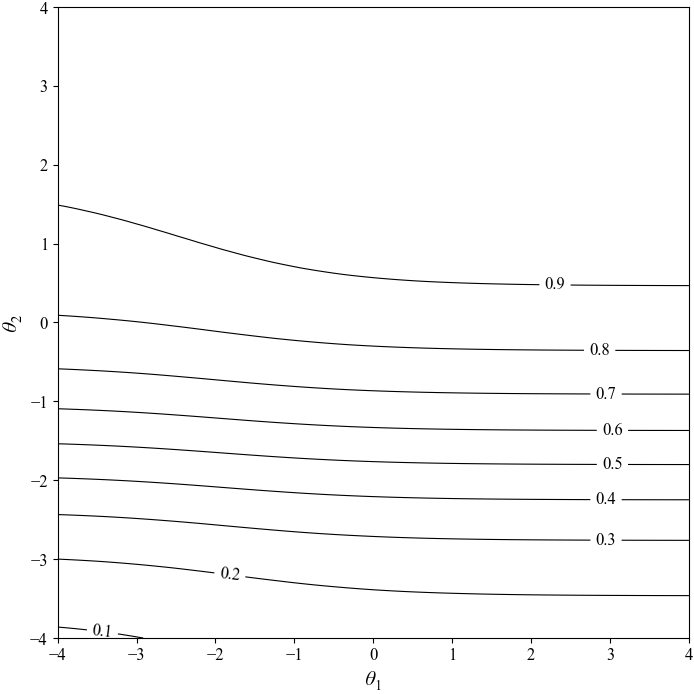

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from calculate_p_lada import lada_probability_vectorized

def plot_item_contour_lada(item_idx, w_df, d_array):
    """
    Generates a 2D Item Characteristic Contour plot in black and white for a single item using LADA parameters.
    """
    if item_idx >= len(w_df) or item_idx >= len(d_array):
        print(f"Error: Item index {item_idx} out of range.")
        return

    # 1. Get parameters for the selected item
    w_params = w_df.iloc[item_idx].values[:2]
    # Ensure d_array is properly indexed - handle both 2D and potentially flattened arrays
    d_item = d_array[item_idx] if d_array.ndim > 1 else d_array
    d_params = d_item[:2] if hasattr(d_item, '__len__') else np.array([d_item, d_item])

    # 2. Create a grid of theta (ability) values
    theta_range = np.linspace(-4, 4, 100)
    theta1_grid, theta2_grid = np.meshgrid(theta_range, theta_range)
    
    # Reshape grid to (n_points, k) for vectorized calculation
    grid_flat = np.column_stack([theta1_grid.ravel(), theta2_grid.ravel()])  # (10000, 2)

    # 3. Calculate the probability of a correct response across the grid (vectorized)
    # Reshape params to (1, k) to work with vectorized function
    w_single = w_params.reshape(1, -1)  # (1, 2)
    d_single = d_params.reshape(1, -1)  # (1, 2)
    
    prob_flat = lada_probability_vectorized(grid_flat, w_single, d_single)  # (10000, 1)
    prob_surface = prob_flat.squeeze().reshape(theta1_grid.shape)

    # 4. Create the 2D contour plot
    fig, ax = plt.subplots(figsize=(8, 7))
    
    contour_lines = ax.contour(theta1_grid, theta2_grid, prob_surface, levels=np.arange(0.1, 1.0, 0.1), colors='black', linewidths=0.8)
    ax.clabel(contour_lines, inline=True, fontsize=12, fmt='%1.1f')

    # 5. Formatting
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_aspect('equal')
    
    plt.show()

# Choose an item to plot
item_to_plot = 4  # Index of the item

# Call the function
plot_item_contour_lada(item_to_plot, w_df_2d, d)

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_30251/1618271532.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


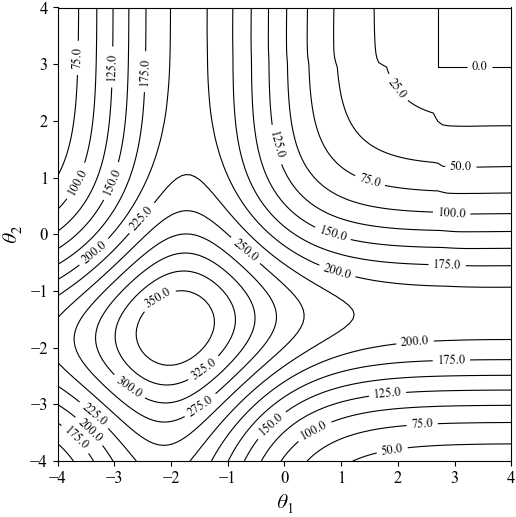

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from calculate_p_lada import lada_probability_vectorized

def plot_test_information_lada(ax, w_df, d_array):
    """
    Calculates and plots the Test Information Contour Map on a given axis for LADA model.
    
    Test Information for LADA is calculated based on the Fisher information.
    For LADA: I(theta) = sum_i [ (dP/dtheta)^2 / (P * (1-P)) ]
    
    Args:
        ax (matplotlib.axes.Axes): The subplot axis to draw on.
        w_df (pd.DataFrame): DataFrame of item weights.
        d_array (np.ndarray): Array of item difficulties.
    """
    # 1. Create a grid of theta values
    theta_range = np.linspace(-4, 4, 100)
    theta1_grid, theta2_grid = np.meshgrid(theta_range, theta_range)
    
    # Reshape grid to (n_points, k) for vectorized calculation
    grid_flat = np.column_stack([theta1_grid.ravel(), theta2_grid.ravel()])  # (10000, 2)
    
    # 2. Get parameters - handle both 1D and 2D arrays
    w_params = w_df.values[:, :2]  # (n_items, 2)
    
    # Handle d_array - ensure it's 2D
    if d_array.ndim == 1:
        # If 1D, assume it's a single item and reshape
        d_params = d_array.reshape(1, -1)[:, :2]
    else:
        d_params = d_array[:, :2]  # (n_items, 2)
    
    # 3. Calculate probabilities for all items at all grid points (vectorized)
    P = lada_probability_vectorized(grid_flat, w_params, d_params)  # (10000, n_items)
    
    # 4. Calculate derivatives numerically for all grid points at once
    epsilon = 1e-5
    total_information_flat = np.zeros(len(grid_flat))
    
    for k in range(2):
        # Perturb theta in dimension k
        grid_plus = grid_flat.copy()
        grid_plus[:, k] += epsilon
        
        # Calculate probabilities at perturbed points
        P_plus = lada_probability_vectorized(grid_plus, w_params, d_params)  # (10000, n_items)
        
        # Numerical derivative: (10000, n_items)
        dP_dtheta_k = (P_plus - P) / epsilon
        
        # Fisher information contribution from this dimension
        # I_k = sum_items [ (dP/dtheta_k)^2 / (P * (1-P)) ]
        mask = (P > 0.01) & (P < 0.99)  # Avoid division by zero
        item_info_k = np.where(mask, dP_dtheta_k**2 / (P * (1 - P)), 0)
        total_information_flat += np.sum(item_info_k, axis=1)
    
    # Reshape back to grid shape
    total_information_surface = total_information_flat.reshape(theta1_grid.shape)

    # 5. Plot the contour on the provided axis
    contour_lines = ax.contour(theta1_grid, theta2_grid, total_information_surface, levels=15, colors='black', linewidths=0.8)
    ax.clabel(contour_lines, inline=True, fontsize=9, fmt='%1.1f')
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_aspect('equal')

# Set up the figure with a single subplot
fig, ax = plt.subplots(1, 1, figsize=(6, 5.5))

# Plot test information
plot_test_information_lada(ax, w_df_2d, d)

plt.tight_layout()
plt.show()

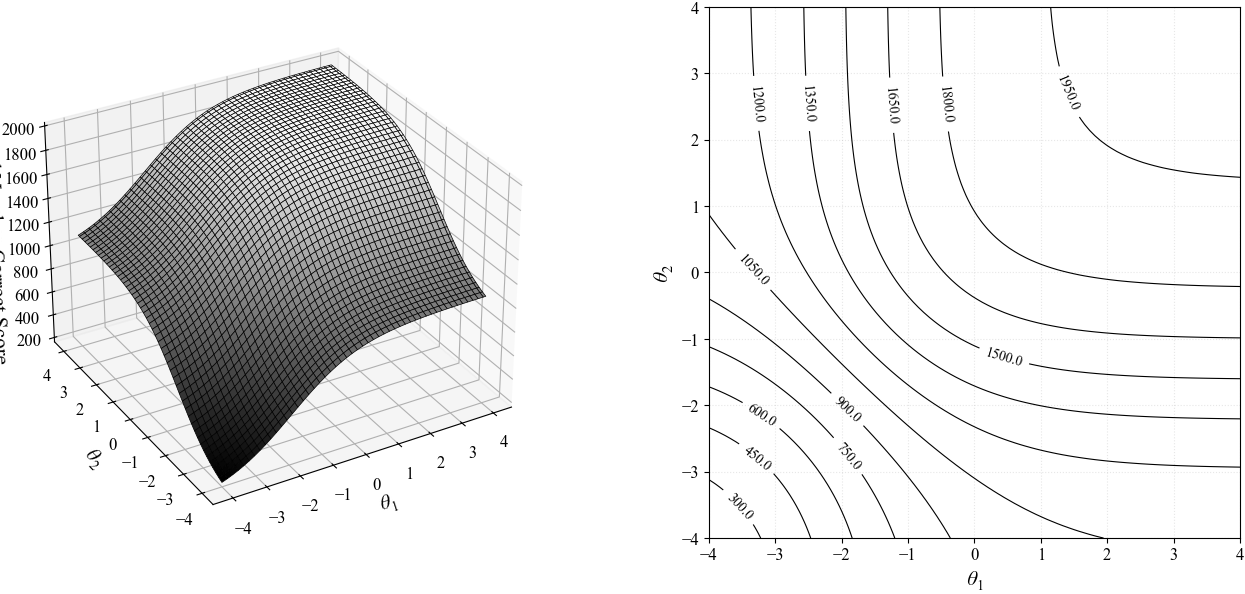

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from calculate_p_lada import lada_probability_vectorized

def plot_test_characteristic_pair_lada(w_df, d_array):
    """
    Calculates and plots the Test Characteristic Surface and its corresponding
    2D contour map for LADA model.

    Args:
        w_df (pd.DataFrame): DataFrame of item weights for the entire test.
        d_array (np.ndarray): Array of item difficulties for the entire test.
    """
    # 1. Create a grid of theta (ability) values
    theta_range = np.linspace(-4, 4, 100)
    theta1_grid, theta2_grid = np.meshgrid(theta_range, theta_range)
    
    # Reshape grid to (n_points, k) for vectorized calculation
    grid_flat = np.column_stack([theta1_grid.ravel(), theta2_grid.ravel()])  # (10000, 2)

    # 2. Get parameters - handle both 1D and 2D arrays
    w_params = w_df.values[:, :2]  # (n_items, 2)
    
    # Handle d_array - ensure it's 2D
    if d_array.ndim == 1:
        # If 1D, assume it's a single item and reshape
        d_params = d_array.reshape(1, -1)[:, :2]
    else:
        d_params = d_array[:, :2]  # (n_items, 2)
    
    # 3. Calculate probabilities for all items at all grid points (vectorized)
    # P: (n_grid_points, n_items)
    P = lada_probability_vectorized(grid_flat, w_params, d_params)
    
    # 4. Sum across items to get expected score at each grid point
    expected_score_flat = np.sum(P, axis=1)  # (10000,)
    expected_score_surface = expected_score_flat.reshape(theta1_grid.shape)

    # 5. Set up the figure with two subplots
    fig = plt.figure(figsize=(14, 6))

    # --- Subplot 1: 3D Surface ---
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    
    ax1.plot_surface(theta1_grid, theta2_grid, expected_score_surface,
                     cmap='gray', linewidth=0.5, edgecolor='black')
    
    ax1.set_xlabel(r'$\theta_1$')
    ax1.set_ylabel(r'$\theta_2$')
    ax1.set_zlabel('Expected Number-Correct Score')
    ax1.view_init(elev=30, azim=-120)

    # --- Subplot 2: 2D Contour Plot ---
    ax2 = fig.add_subplot(1, 2, 2)

    contour_lines = ax2.contour(theta1_grid, theta2_grid, expected_score_surface, levels=15, colors='black', linewidths=0.8)
    ax2.clabel(contour_lines, inline=True, fontsize=10, fmt='%1.1f')

    ax2.set_xlabel(r'$\theta_1$')
    ax2.set_ylabel(r'$\theta_2$')
    ax2.grid(True, linestyle=':', alpha=0.3)
    ax2.set_aspect('equal')
    plt.show()

# Call the function
plot_test_characteristic_pair_lada(w_df_2d, d)

# Scenario-specific performance analysis

In [9]:
import pandas as pd

model_spec = pd.read_csv('../data-reeval-multi/model_specs.csv')
model_spec.dropna(subset=['size'], inplace=True)
model_spec.sort_values(by='size', ascending=False, inplace=True)
model_spec_llama = model_spec[model_spec['code'].str.contains('meta/', case=False, na=False)]

print(f"Model spec shape: {model_spec.shape}")
model_spec.head()

Model spec shape: (118, 5)


,code,name,size,pretrain,flops
42,microsoft/TNLGv2_530B,TNLG v2 (530B),530.0,0.27,143.1
115,snowflake/snowflake-arctic-instruct,Arctic Instruct,480.0,0.40,768.0
163,meta/llama-3.1-405b-instruct-turbo,Llama 3.1 Instruct Turbo (405B),405.0,15.00,36450.0
52,ai21/j2-jumbo,Jurassic-2 Jumbo (178B),178.0,1.20,213.6
50,ai21/j1-jumbo,J1-Jumbo v1 (178B),178.0,0.30,53.4


In [10]:
# Prepare theta scores with EAP estimates
theta_score_df = theta_df.rename(columns={'Factor_1': 'f1', 'Factor_2': 'f2'}).copy()
theta_score_df['accuracy'] = accuracy
theta_score_df['irt'] = theta_irt.values
theta_score_df.dropna(how='any', inplace=True)
theta_score_df = theta_score_df.round(6)

print(f"Theta score DataFrame shape: {theta_score_df.shape}")
theta_score_df.head()

Theta score DataFrame shape: (91, 4)


,f1,f2,accuracy,irt
request.model,,,,
allenai/olmo-7b,0.098950,-1.509060,0.386079,-1.071928
cohere/command-light,2.073788,-3.330914,0.410115,-0.945389
AlephAlpha/luminous-base,1.562983,-2.791275,0.406610,-0.982251
cohere/command,-1.205221,0.806234,0.505258,-0.348166
mistralai/mistral-7b-instruct-v0.3,-1.696037,-0.140001,0.377066,-1.153409


In [11]:
# Calculate Linear Predictor: L = d + W^T * theta
# For each model, compute the average linear predictor across all items

# Get the factor loadings (W) and difficulties (d) for the first 2 factors
w_params = w_df[['Factor_1', 'Factor_2']].values  # (n_items, 2)
d_params = d[:, :2] if d.ndim > 1 else d.reshape(-1, 1)[:, :2]  # (n_items, 2)

# For each model, calculate the linear predictor for each item, then average
linear_predictors = []
for model_idx in theta_score_df.index:
    if model_idx in theta_df.index:
        # Get theta for this model (2 factors)
        theta_model = theta_df.loc[model_idx, ['Factor_1', 'Factor_2']].values  # (2,)
        
        # Calculate L = d + W^T * theta for all items
        # W^T * theta: (n_items, 2) @ (2,) = (n_items,)
        linear_pred_items = d_params.sum(axis=1) + (w_params @ theta_model)
        
        # Average across all items to get a single score for this model
        avg_linear_pred = linear_pred_items.mean()
        linear_predictors.append(avg_linear_pred)
    else:
        linear_predictors.append(np.nan)

theta_score_df['linear_pred'] = linear_predictors

print(f"Linear predictor statistics:")
print(theta_score_df['linear_pred'].describe())

Linear predictor statistics:
count    91.000000
mean      0.240369
std       0.595699
min      -1.407006
25%      -0.129054
50%       0.413862
75%       0.672540
max       1.114247
Name: linear_pred, dtype: float64


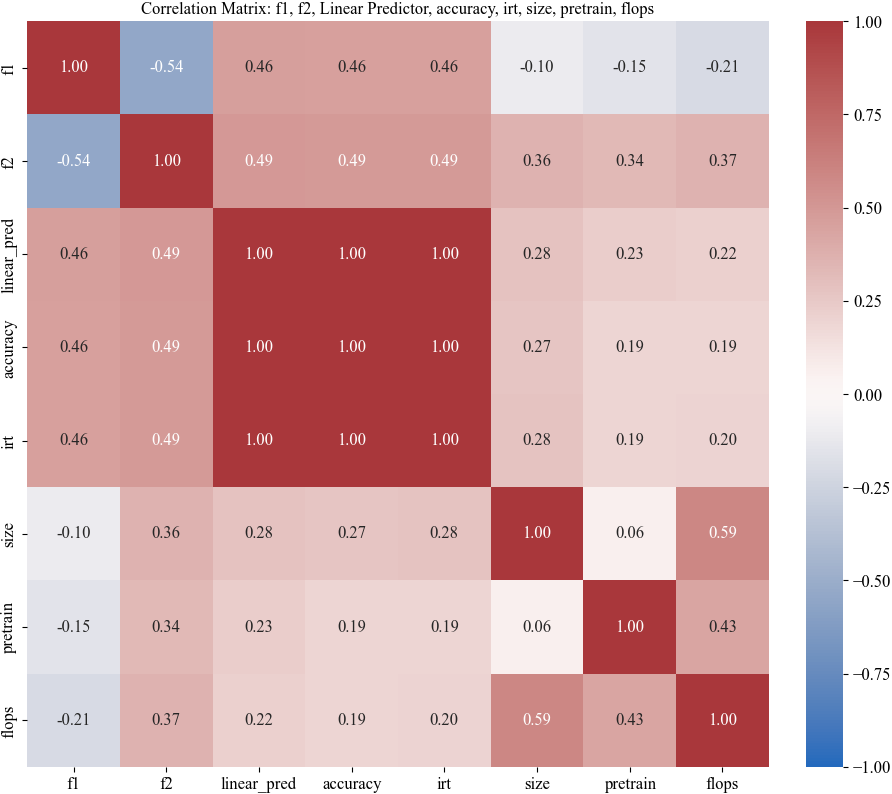

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Join model specs for the extended correlation analysis
model_score_df = theta_score_df.join(model_spec.set_index("code"), how="left")

# Select relevant columns including the new linear predictor
corr_cols_extended = ['f1', 'f2', 'linear_pred', 'accuracy', 'irt', 'size', 'pretrain', 'flops']
corr_extended_df = model_score_df[corr_cols_extended].copy()

# Compute correlation matrix
corr_matrix_extended = corr_extended_df.corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr_matrix_extended, annot=True, cmap='vlag', fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix: f1, f2, Linear Predictor, accuracy, irt, size, pretrain, flops")
fig.set_constrained_layout(True)
plt.show()

In [13]:
model_score_df.dropna(subset=['f1', 'f2'], inplace=True)
model_score_llama_df = model_score_df.loc[model_score_df.index.str.contains('meta/', case=False, na=False)].copy()

In [14]:
model_score_llama_df.sort_values(by='irt', ascending=False)

,f1,f2,accuracy,irt,linear_pred,name,size,pretrain,flops
request.model,,,,,,,,,
meta/llama-3-70b,1.852748,0.119297,0.709064,1.003420,1.114247,Llama 3 (70B),70.0,15.0,6300.00
meta/llama-3.3-70b-instruct-turbo,-0.589726,1.716840,0.636455,0.534248,0.726390,Llama 3.3 Instruct Turbo (70B),70.0,15.0,635.00
meta/llama-2-70b,1.452699,-0.359598,0.643966,0.530966,0.674100,Llama 2 (70B),70.0,2.0,840.00
meta/llama-3-8b,1.941608,-0.998411,0.619930,0.339373,0.589487,Llama 3 (8B),8.0,15.0,720.00
meta/llama-2-13b,2.024447,-1.288495,0.603906,0.262073,0.482670,Llama 2 (13B),13.0,2.0,156.00
meta/llama-3.1-405b-instruct-turbo,-1.364481,2.087383,0.594392,0.251040,0.534095,Llama 3.1 Instruct Turbo (405B),405.0,15.0,36450.00
meta/llama-3.1-70b-instruct-turbo,-1.222292,2.093483,0.597396,0.229226,0.607074,Llama 3.1 Instruct Turbo (70B),70.0,15.0,6300.00
meta/llama-3.2-90b-vision-instruct-turbo,-1.477635,2.154302,0.590886,0.152692,0.512520,Llama 3.2 Vision Instruct Turbo (90B),90.0,NaN,797.00
meta/llama-2-7b,1.787577,-1.683341,0.542814,-0.118701,0.165459,Llama 2 (7B),7.0,2.0,84.00
